# NetworkX Talk - Evening of Python Coding
## Graph Introduction with NetworkX and Matplotlib

This notebook demonstrates different types of graphs and how they can be used to represent:
1. Social media relationships
2. Common computer science data structures

**Date:** October 21, 2025

## Setup and Imports
First, let's import the necessary libraries.

In [83]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Configure matplotlib for inline display in notebooks
%matplotlib inline

---
# Part 1: Social Media Networks

Let's explore how graphs can model different social media platforms.

## 1. Facebook Friend Network (Undirected Graph)

In Facebook, friendships are **bidirectional** (mutual) - if Alice is friends with Bob, then Bob is friends with Alice. We represent this with an undirected graph.

In [20]:
# Create a Graph to represent Facebook friendships
G = nx.Graph()

# Add users as nodes
users = ["Alice", "Bob", "Charlie", "Diana", "Eve", "Frank"]
G.add_nodes_from(users)

# Add friendships as edges (bidirectional)
friendships = [
    ("Alice", "Bob"),
    ("Alice", "Charlie"),
    ("Bob", "Diana"),
    ("Charlie", "Diana"),
    ("Diana", "Eve"),
    ("Eve", "Frank"),
    ("Frank", "Alice")
]
G.add_edges_from(friendships)

print(f"Nodes: {G.nodes()}")
print(f"Edges: {G.edges()}")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

Nodes: ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve', 'Frank']
Edges: [('Alice', 'Bob'), ('Alice', 'Charlie'), ('Alice', 'Frank'), ('Bob', 'Diana'), ('Charlie', 'Diana'), ('Diana', 'Eve'), ('Eve', 'Frank')]
Number of nodes: 6
Number of edges: 7


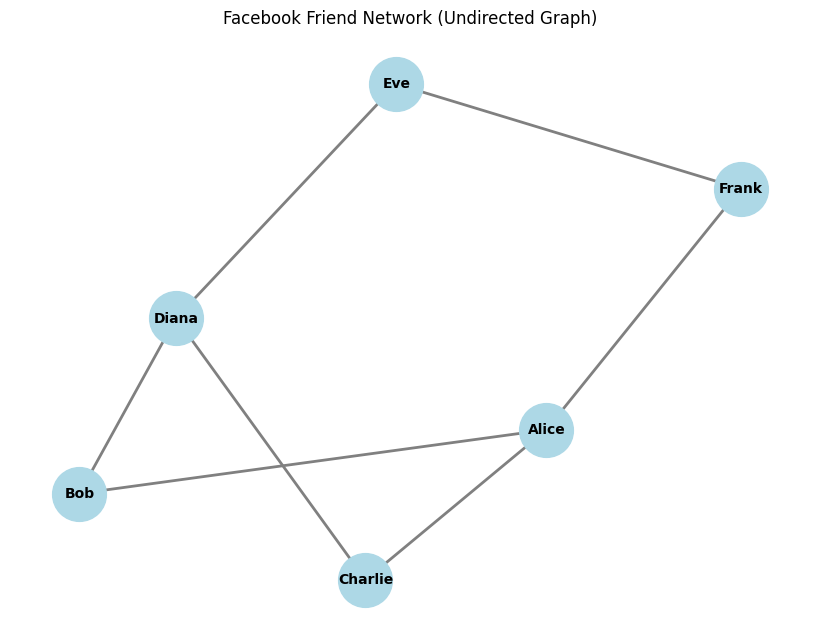

In [21]:
# Visualize the Facebook friend network
plt.figure(figsize=(8, 6))
nx.draw(G, with_labels=True, node_color='lightblue', 
        node_size=1500, font_size=10, font_weight='bold',
        edge_color='gray', width=2)
plt.title("Facebook Friend Network (Undirected Graph)")
plt.show()

## 2. Twitter Following Network (Directed Graph)

In Twitter, following is **directional** - Alice can follow Bob without Bob following Alice back. We use a directed graph (DiGraph) for this.

In [22]:
# Create a DiGraph to represent Twitter following relationships
DG = nx.DiGraph()

# Add users as nodes
users = ["Alice", "Bob", "Charlie", "Diana", "Eve"]
DG.add_nodes_from(users)

# Add following relationships (directional: follower -> followed)
following = [
    ("Alice", "Bob"),      # Alice follows Bob
    ("Alice", "Charlie"),  # Alice follows Charlie
    ("Bob", "Charlie"),
    ("Charlie", "Diana"),
    ("Diana", "Alice"),
    ("Diana", "Eve"),
    ("Eve", "Alice")
]
DG.add_edges_from(following)

print(f"Nodes: {DG.nodes()}")
print(f"Edges: {DG.edges()}")
print(f"Alice follows: {list(DG.successors('Alice'))}")
print(f"Alice is followed by: {list(DG.predecessors('Alice'))}")

Nodes: ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve']
Edges: [('Alice', 'Bob'), ('Alice', 'Charlie'), ('Bob', 'Charlie'), ('Charlie', 'Diana'), ('Diana', 'Alice'), ('Diana', 'Eve'), ('Eve', 'Alice')]
Alice follows: ['Bob', 'Charlie']
Alice is followed by: ['Diana', 'Eve']


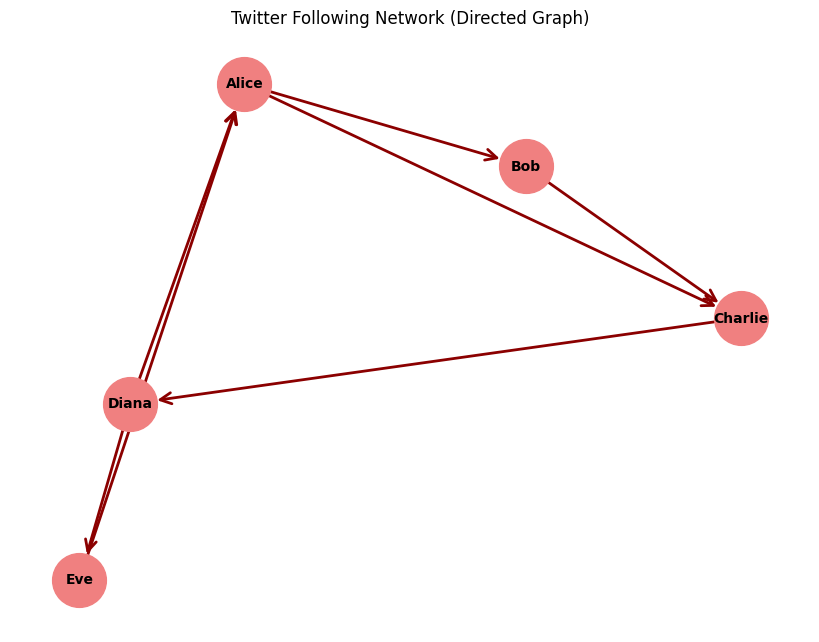

In [37]:
# Visualize the Twitter following network
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(DG, seed=42)
nx.draw(DG, pos, with_labels=True, node_color='lightcoral',
        node_size=1500, font_size=10, font_weight='bold',
        edge_color='darkred', width=2, arrows=True,
        arrowsize=20, arrowstyle='->')
plt.title("Twitter Following Network (Directed Graph)")
plt.show()

## 3. Multi-Relationship Network (MultiGraph)

Sometimes people have **multiple types of relationships**. A MultiGraph allows multiple edges between the same nodes.

In [24]:
# Create a MultiGraph to show multiple relationships between same nodes
MG = nx.MultiGraph()

# Add nodes
people = ["Alice", "Bob", "Charlie"]
MG.add_nodes_from(people)

# Add multiple edges between same nodes with different relationship types
MG.add_edge("Alice", "Bob", relationship="friend")
MG.add_edge("Alice", "Bob", relationship="colleague")
MG.add_edge("Bob", "Charlie", relationship="neighbor")
MG.add_edge("Bob", "Charlie", relationship="friend")
MG.add_edge("Alice", "Charlie", relationship="colleague")

print(f"Nodes: {MG.nodes()}")
print(f"Edges: {MG.edges()}")
print(f"Number of edges between Alice and Bob: {MG.number_of_edges('Alice', 'Bob')}")

Nodes: ['Alice', 'Bob', 'Charlie']
Edges: [('Alice', 'Bob'), ('Alice', 'Bob'), ('Alice', 'Charlie'), ('Bob', 'Charlie'), ('Bob', 'Charlie')]
Number of edges between Alice and Bob: 2


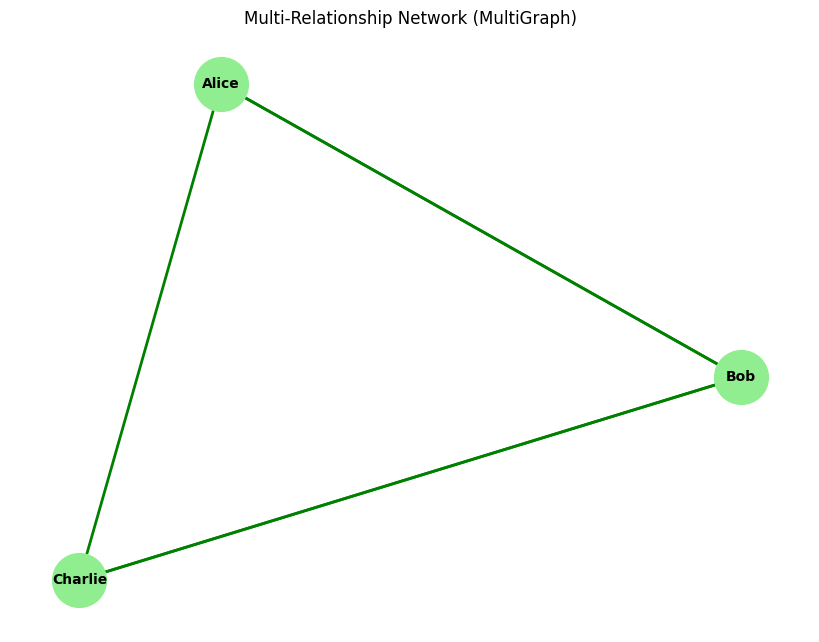

In [25]:
# Visualize the multi-relationship network
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(MG, seed=42)
nx.draw(MG, pos, with_labels=True, node_color='lightgreen',
        node_size=1500, font_size=10, font_weight='bold',
        edge_color='green', width=2)
plt.title("Multi-Relationship Network (MultiGraph)")
plt.show()

## 4. Multi-Directional Interactions (MultiDiGraph)

For platforms with multiple types of **directed** interactions (messages, likes, shares), we use MultiDiGraph.

In [26]:
# Create a MultiDiGraph for multiple directed relationships
MDG = nx.MultiDiGraph()

# Add nodes
users = ["Alice", "Bob", "Charlie"]
MDG.add_nodes_from(users)

# Add multiple directed edges with different interaction types
MDG.add_edge("Alice", "Bob", interaction="message")
MDG.add_edge("Alice", "Bob", interaction="like")
MDG.add_edge("Bob", "Alice", interaction="message")
MDG.add_edge("Bob", "Charlie", interaction="share")
MDG.add_edge("Charlie", "Bob", interaction="like")
MDG.add_edge("Charlie", "Bob", interaction="message")

print(f"Nodes: {MDG.nodes()}")
print(f"Edges: {MDG.edges()}")
print(f"Number of edges from Alice to Bob: {MDG.number_of_edges('Alice', 'Bob')}")

Nodes: ['Alice', 'Bob', 'Charlie']
Edges: [('Alice', 'Bob'), ('Alice', 'Bob'), ('Bob', 'Alice'), ('Bob', 'Charlie'), ('Charlie', 'Bob'), ('Charlie', 'Bob')]
Number of edges from Alice to Bob: 2


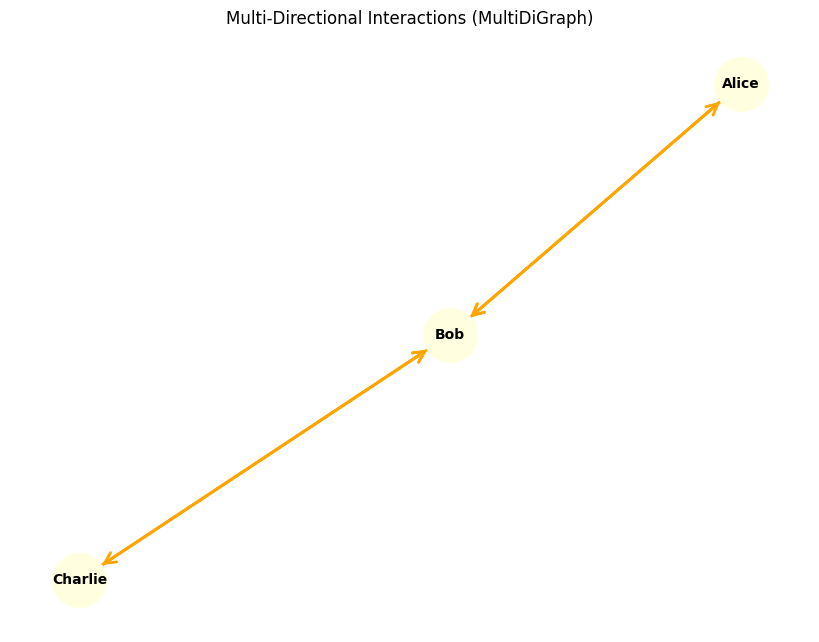

In [27]:
# Visualize the multi-directional interactions
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(MDG, seed=42)
nx.draw(MDG, pos, with_labels=True, node_color='lightyellow',
        node_size=1500, font_size=10, font_weight='bold',
        edge_color='orange', width=2, arrows=True,
        arrowsize=20, arrowstyle='->')
plt.title("Multi-Directional Interactions (MultiDiGraph)")
plt.show()

---
# Part 2: Computer Science Data Structures as Graphs

Many classic data structures can be represented as graphs!

## 5. Linked List (Path Graph)

A linked list is a sequence of nodes where each node points to the next. We can represent this as a **path graph**.

In [93]:
# Create a Linked List as a path graph
LL = nx.path_graph(5, create_using=nx.DiGraph())

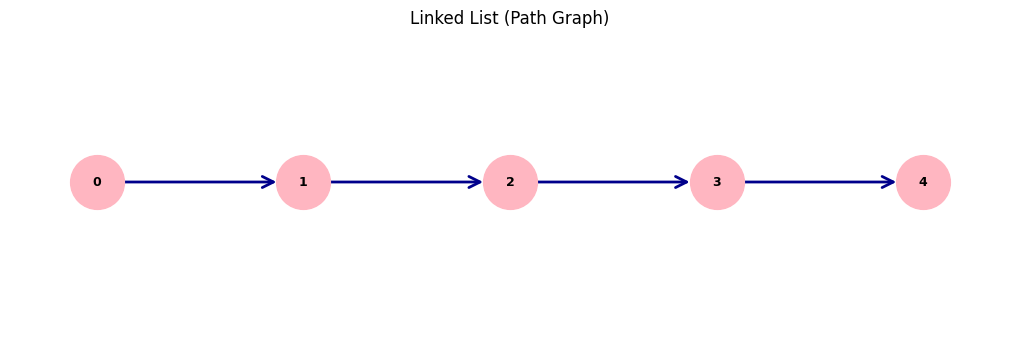

In [98]:
plt.figure(figsize=(10, 3))

pos = {node: (i, 0) for i, node in enumerate(LL.nodes())} # linear layout
nx.draw(LL, pos, with_labels=True, node_color='lightpink',
        node_size=1500, font_size=9, font_weight='bold',
        edge_color='darkblue', width=2, arrows=True,
        arrowsize=20, arrowstyle='->')
plt.title("Linked List (Path Graph)")
plt.show()

## 6. Binary Tree (Acyclic Graph)

Trees are **connected acyclic graphs** commonly used in computer science. Let's create a balanced binary tree.

In [100]:
# Create a balanced binary tree
Tree = nx.balanced_tree(2, 3, create_using=nx.DiGraph())

print(f"Number of nodes: {Tree.number_of_nodes()}")
print(f"Number of edges: {Tree.number_of_edges()}")
print(f"Is acyclic: {nx.is_directed_acyclic_graph(Tree)}")
print(f"Is tree: {nx.is_tree(Tree)}")

Number of nodes: 15
Number of edges: 14
Is acyclic: True
Is tree: True


/var/folders/xn/jf07n1j1221738g7pgyb5dww0000gn/T/ipykernel_13672/1170687634.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


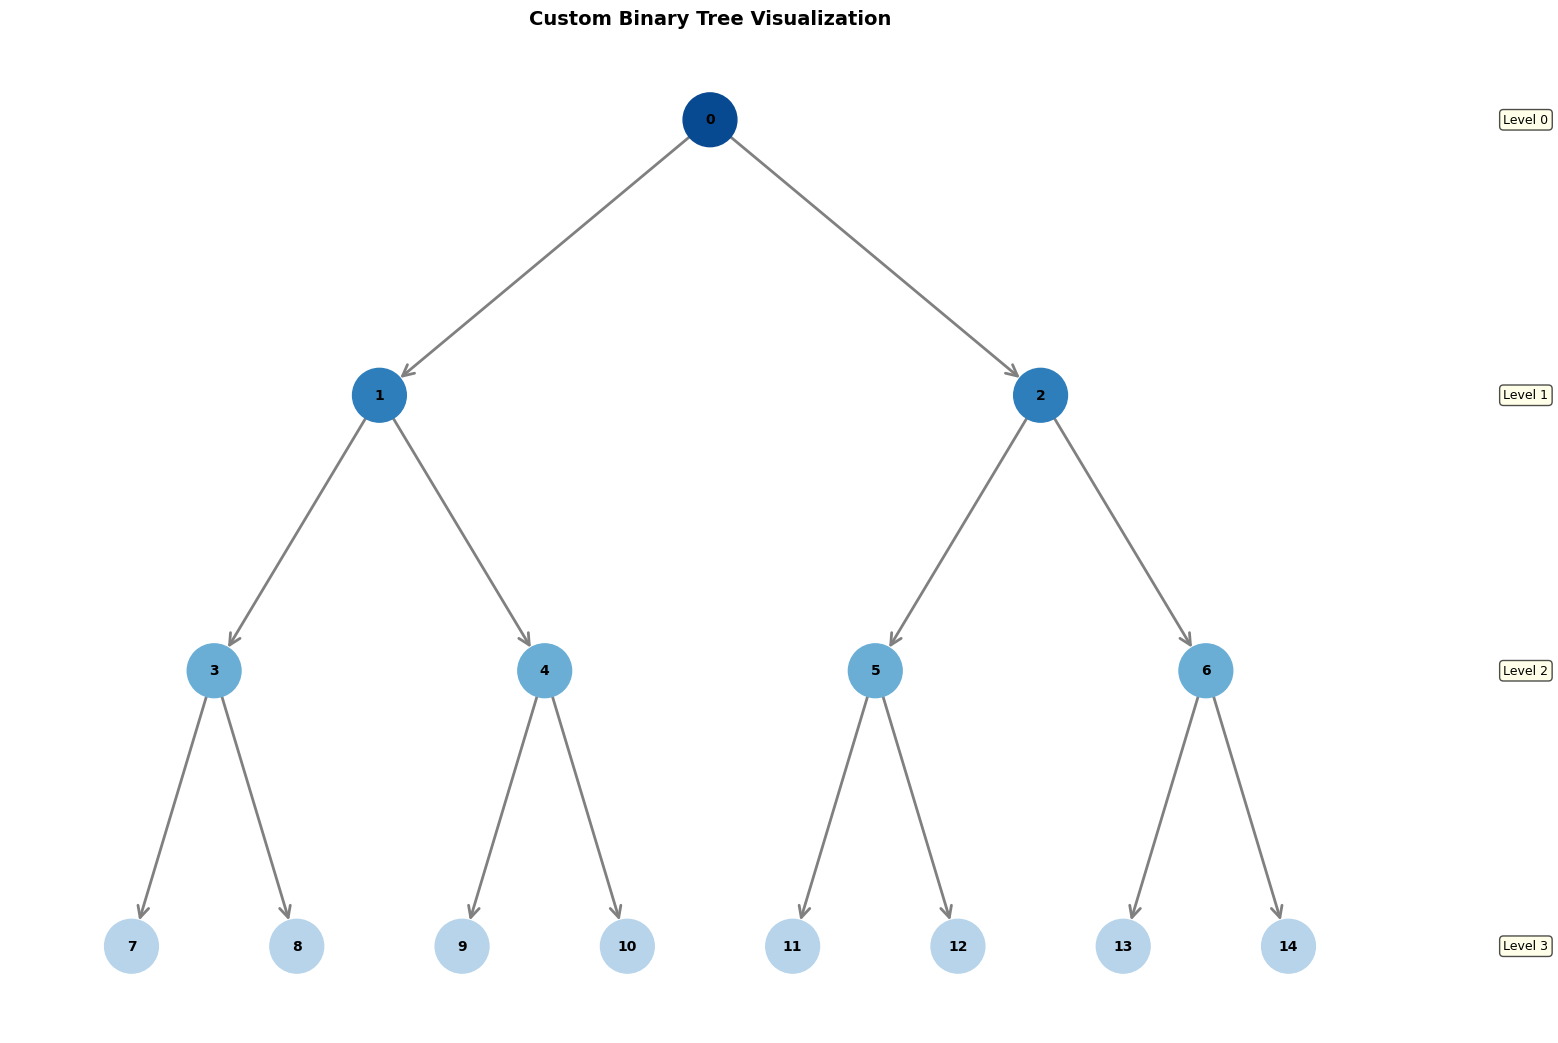

In [101]:
def hierarchy_pos(G, root=None, width=1., vert_gap=0.2, vert_loc=0, xcenter=0.5):
    """
    Create a hierarchical tree layout with proper multi-level positioning.

    Parameters:
    -----------
    G : networkx graph
        The tree to layout
    root : node
        Root node of tree
    width : float
        Width of the tree layout
    vert_gap : float
        Gap between levels (vertical spacing)
    vert_loc : float
        Vertical location of root
    xcenter : float
        Horizontal location of root
    """
    if not nx.is_tree(G):
        raise TypeError('cannot use hierarchy_pos on a graph that is not a tree')

    if root is None:
        if isinstance(G, nx.DiGraph):
            root = [n for n in G.nodes() if G.in_degree(n) == 0][0]
        else:
            root = list(G.nodes())[0]

    def _hierarchy_pos(G, node, left, right, vert_loc, pos, parent=None):
        pos[node] = ((left + right) / 2, vert_loc)
        children = list(G.successors(node))
        if len(children) != 0:
            dx = (right - left) / len(children)
            nextx = left + dx / 2
            for child in children:
                pos = _hierarchy_pos(G, child, nextx - dx/2, nextx + dx/2,
                                   vert_loc - vert_gap, pos, node)
                nextx += dx
        return pos

    return _hierarchy_pos(G, root, 0, width, vert_loc, {})

def draw_tree(Tree, figsize=(12, 8), title="Binary Tree - Multi-level Hierarchy"):
    """
    Draw the tree with hierarchical layout showing multiple levels clearly

    Parameters:
    -----------
    Tree : networkx DiGraph
        The tree to draw
    figsize : tuple
        Figure size (width, height)
    title : str
        Title for the plot
    """
    plt.figure(figsize=figsize)

    # Get hierarchical positions
    pos = hierarchy_pos(Tree, root=0, width=1., vert_gap=0.2)

    # Get node labels if they exist
    labels = nx.get_node_attributes(Tree, 'label')
    if not labels:
        labels = {node: str(node) for node in Tree.nodes()}

    # Calculate level for each node (for coloring)
    levels = nx.single_source_shortest_path_length(Tree, 0)
    max_level = max(levels.values())

    # Color nodes by level
    node_colors = []
    color_map = plt.cm.Blues  # You can change this colormap
    for node in Tree.nodes():
        level = levels[node]
        # Normalize level to [0.3, 0.9] for better visibility
        color_intensity = 0.3 + (0.6 * (max_level - level) / max(max_level, 1))
        node_colors.append(color_map(color_intensity))

    # Draw the tree
    nx.draw(Tree, pos,
            labels=labels,
            with_labels=True,
            node_color=node_colors,
            node_size=1500,
            font_size=10,
            font_weight='bold',
            edge_color='gray',
            width=2,
            arrows=True,
            arrowsize=20,
            arrowstyle='->',
            min_target_margin=15)

    # Add level annotations
    ax = plt.gca()
    level_y_positions = {}
    for node, (x, y) in pos.items():
        level = levels[node]
        if level not in level_y_positions:
            level_y_positions[level] = y

    # Add level labels on the right side
    for level, y_pos in level_y_positions.items():
        ax.text(1.1, y_pos, f'Level {level}',
                fontsize=9, ha='left', va='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.7))

    plt.title(title, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    Tree = nx.balanced_tree(2, 3, create_using=nx.DiGraph())
    #Tree = create_binary_tree()
    draw_tree(Tree, figsize=(14, 10), title="Custom Binary Tree Visualization")

## 7. Stack (LIFO Structure)

A stack is a **Last-In-First-Out (LIFO)** data structure. Elements are added and removed from the top.

In [40]:
# Create a Stack representation as a graph
Stack = nx.DiGraph()

# Stack elements (bottom to top)
elements = ["Bottom", "Element_1", "Element_2", "Element_3", "Top"]
Stack.add_nodes_from(elements)

# Add edges showing the stack order (bottom points to top)
for i in range(len(elements) - 1):
    Stack.add_edge(elements[i], elements[i + 1])

print(f"Stack elements (bottom to top): {elements}")
print(f"Nodes: {list(Stack.nodes())}")
print("Operations: Push adds to top, Pop removes from top")

Stack elements (bottom to top): ['Bottom', 'Element_1', 'Element_2', 'Element_3', 'Top']
Nodes: ['Bottom', 'Element_1', 'Element_2', 'Element_3', 'Top']
Operations: Push adds to top, Pop removes from top


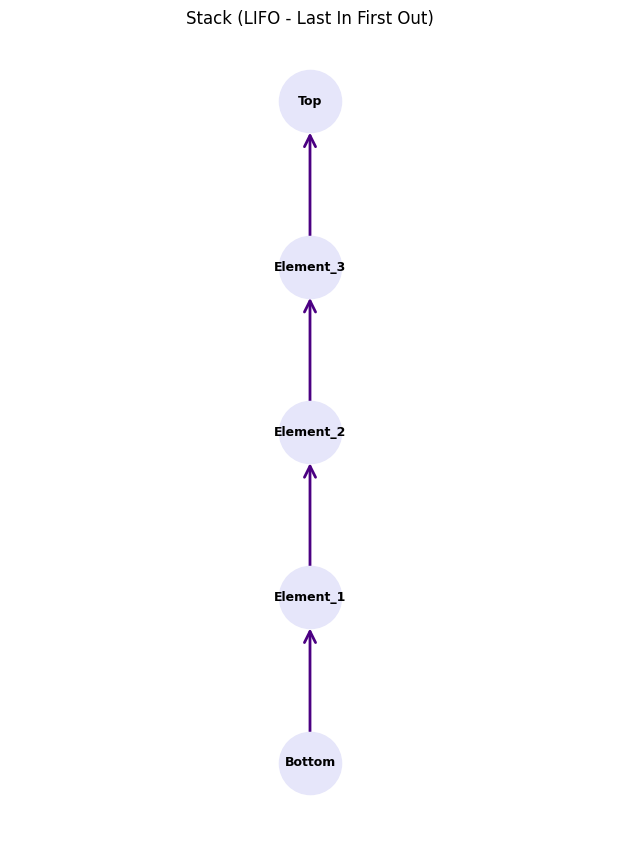

In [41]:
# Visualize the stack
plt.figure(figsize=(6, 8))
# Create a vertical layout for stack
pos = {node: (0, i) for i, node in enumerate(elements)}
nx.draw(Stack, pos, with_labels=True, node_color='lavender',
        node_size=2000, font_size=9, font_weight='bold',
        edge_color='indigo', width=2, arrows=True,
        arrowsize=20, arrowstyle='->')
plt.title("Stack (LIFO - Last In First Out)")
plt.show()

## 8. Deque (Double-Ended Queue)

A **deque** (double-ended queue) allows insertion and deletion from both ends.

In [34]:
# Create a Double-Ended Queue (Deque) representation
Deque = nx.Graph()  # Undirected since we can access both ends

# Deque elements
elements = ["Left_End", "Element_1", "Element_2", "Element_3", "Right_End"]
Deque.add_nodes_from(elements)

# Add edges connecting elements in sequence
for i in range(len(elements) - 1):
    Deque.add_edge(elements[i], elements[i + 1])

print(f"Deque elements: {elements}")
print(f"Nodes: {list(Deque.nodes())}")
print("Operations: Can add/remove from both Left_End and Right_End")

Deque elements: ['Left_End', 'Element_1', 'Element_2', 'Element_3', 'Right_End']
Nodes: ['Left_End', 'Element_1', 'Element_2', 'Element_3', 'Right_End']
Operations: Can add/remove from both Left_End and Right_End


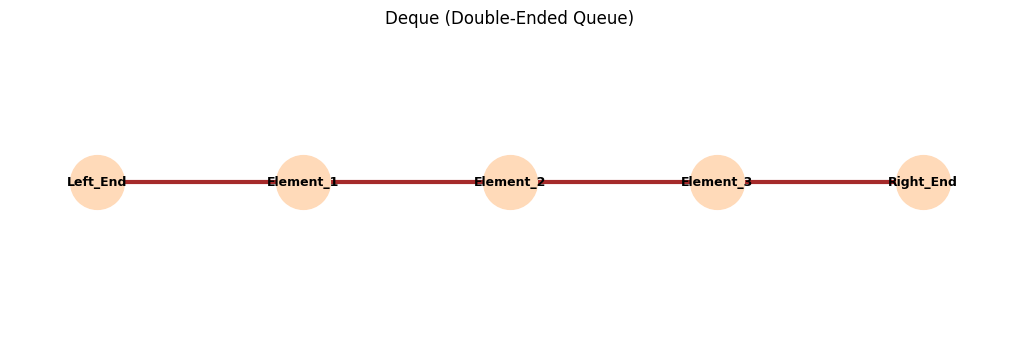

In [35]:
# Visualize the deque
plt.figure(figsize=(10, 3))
# Create a horizontal layout for deque
pos = {node: (i, 0) for i, node in enumerate(elements)}
nx.draw(Deque, pos, with_labels=True, node_color='peachpuff',
        node_size=1500, font_size=9, font_weight='bold',
        edge_color='brown', width=3)
plt.title("Deque (Double-Ended Queue)")
plt.show()

### Graph Types:
- **Graph**: Undirected edges (mutual relationships like Facebook)
- **DiGraph**: Directed edges (one-way relationships like Twitter)
- **MultiGraph**: Multiple undirected edges between same nodes
- **MultiDiGraph**: Multiple directed edges between same nodes

### Data Structures:
- **Path Graph**: Linear sequences (linked lists)
- **Acyclic Graphs**: Hierarchical structures (trees)
- **Specialized Layouts**: Stacks (LIFO) and Deque's (double-ended access)


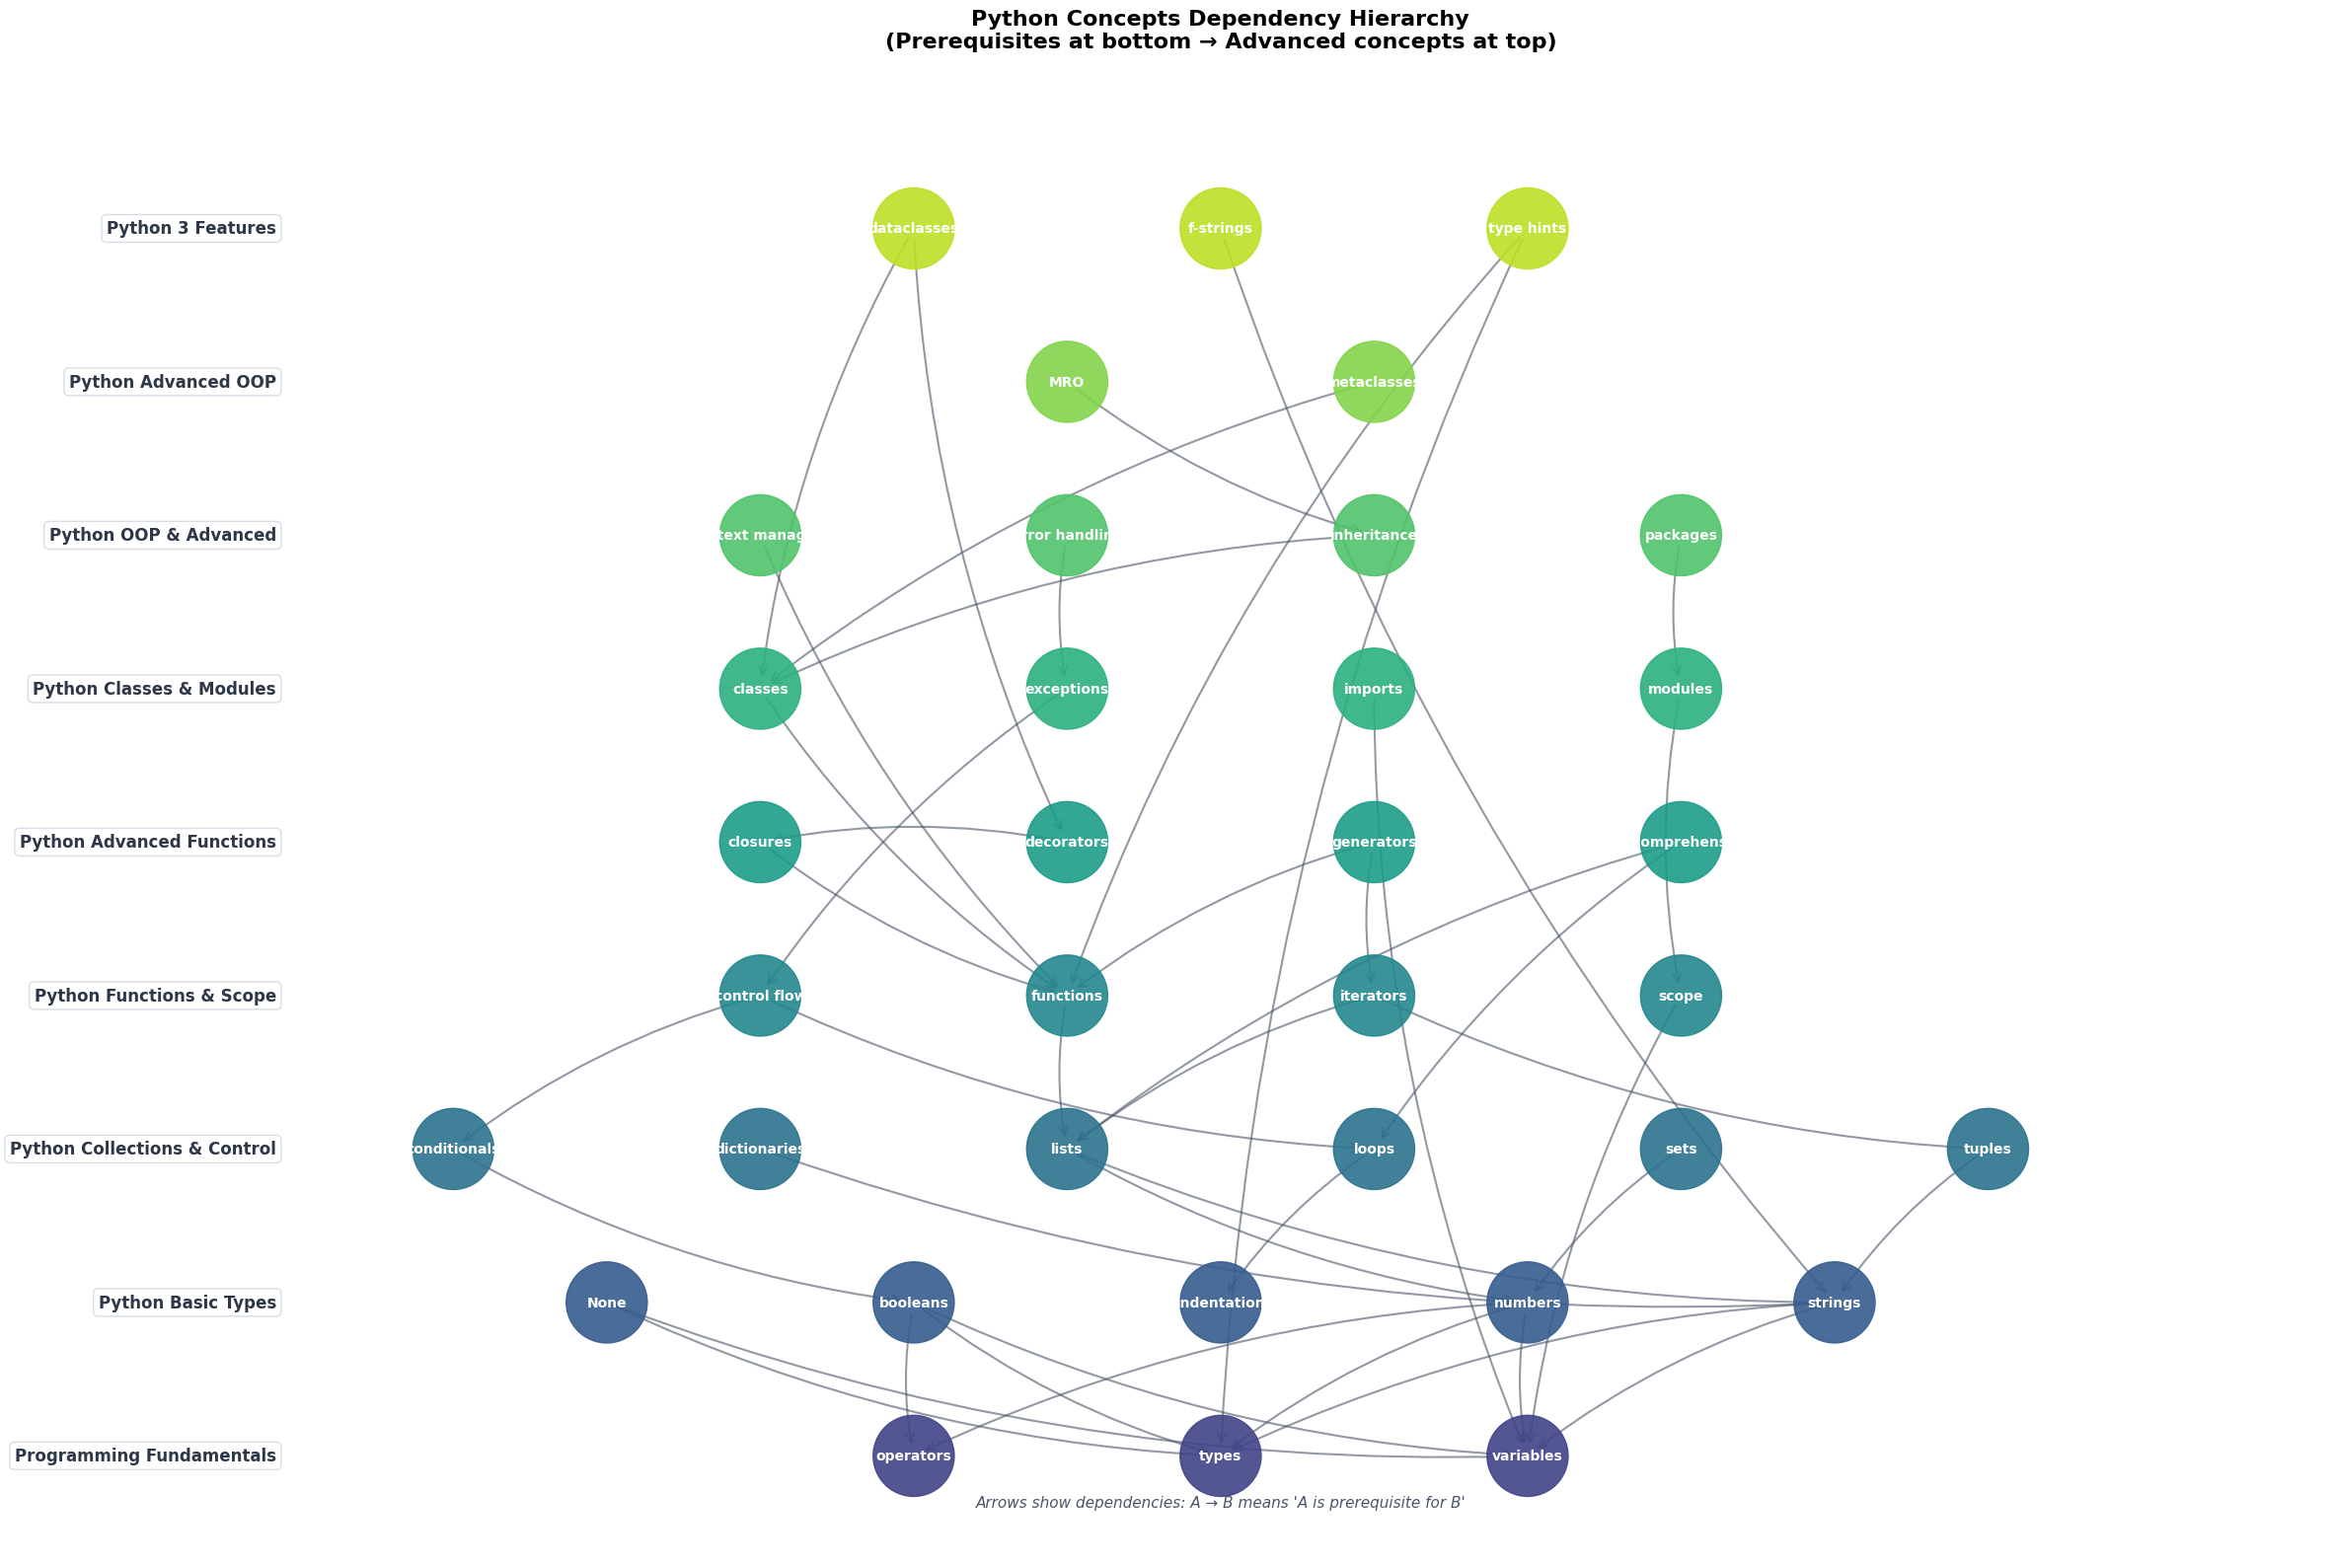

In [86]:
Concepts = nx.DiGraph()

categories = [
    "Programming Fundamentals",
    "Python Basic Types",
    "Python Collections & Control",
    "Python Functions & Scope",
    "Python Advanced Functions",
    "Python Classes & Modules",
    "Python OOP & Advanced",
    "Python Advanced OOP",
    "Python 3 Features"
]

# Level 0: Fundamental primitives
level_0 = [
    "python operators",
    "python variables",
    "python types",

]

# Level 1: Basic data types
level_1 = [
    "python numbers",
    "python booleans",
    "python None",
    "python strings",
    "python indentation",
]

# Level 2: Collections and basic control
level_2 = [
    "python lists",
    "python tuples",
    "python dictionaries",
    "python sets",
    "python conditionals",
    "python loops",
]

# Level 3: Functions and scope
level_3 = [
    "python functions",
    "python scope",
    "python control flow",
    "python iterators",
]

# Level 4: Advanced functions
level_4 = [
    "python generators",
    "python list comprehensions",
    "python decorators",
    "python closures",
]

# Level 5: Classes and modules
level_5 = [
    "python classes",
    "python modules",
    "python imports",
    "python exceptions",
]

# Level 6: OOP and advanced
level_6 = [
    "python inheritance",
    "python packages",
    "python context managers",
    "python error handling",
]

# Level 7: Advanced OOP
level_7 = [
    "python MRO",
    "python metaclasses",
]

# Level 8: Python 3 features
level_8 = [
    "python v3 f-strings",
    "python v3 dataclasses",
    "python v3 type hints",
]

# Combine all levels
all_levels = [level_0, level_1, level_2, level_3, level_4, level_5, level_6, level_7, level_8]

# Add all nodes
for level in all_levels:
    for concept in level:
        Concepts.add_node(concept)

# Define edges (prerequisite -> dependent)
# Format: (from_node, to_node) where from_node is prerequisite

edges = [
    # Level 0 -> Level 1
    ("python types", "python numbers"),
    ("python types", "python booleans"),
    ("python types", "python None"),
    ("python types", "python strings"),
    ("python operators", "python numbers"),
    ("python operators", "python booleans"),
    ("python variables", "python strings"),
    ("python variables", "python numbers"),
    ("python variables", "python booleans"),
    ("python variables", "python None"),


    # Level 1 -> Level 2
    ("python booleans", "python conditionals"),
    ("python numbers", "python lists"),
    ("python strings", "python lists"),
    ("python strings", "python tuples"),
    ("python strings", "python dictionaries"),
    ("python numbers", "python sets"),
    ("python indentation", "python loops"),

    # Level 2 -> Level 3
    ("python conditionals", "python control flow"),
    ("python loops", "python control flow"),
    ("python lists", "python iterators"),
    ("python tuples", "python iterators"),
    ("python variables", "python scope"),
    ("python lists", "python functions"),

    # Level 3 -> Level 4
    ("python functions", "python closures"),
    ("python closures", "python decorators"),
    ("python iterators", "python generators"),
    ("python loops", "python list comprehensions"),
    ("python lists", "python list comprehensions"),
    ("python functions", "python generators"),

    # Level 3/4'ish -> Level 5
    ("python functions", "python classes"),
    ("python scope", "python modules"),
    ("python control flow", "python exceptions"),
    ("python variables", "python imports"),

    # Level 5 -> Level 6
    ("python classes", "python inheritance"),
    ("python modules", "python packages"),
    ("python functions", "python context managers"),
    ("python exceptions", "python error handling"),

    # Level 6 -> Level 7
    ("python inheritance", "python MRO"),
    ("python classes", "python metaclasses"),

    # Dependencies for Python 3 features
    ("python strings", "python v3 f-strings"),
    ("python classes", "python v3 dataclasses"),
    ("python decorators", "python v3 dataclasses"),
    ("python types", "python v3 type hints"),
    ("python functions", "python v3 type hints"),
]

# Add edges to graph
Concepts.add_edges_from(edges)
# show the arrow direction from the teachers perspective instead of the students
Concepts = Concepts.reverse()

# Create hierarchical layout with proper spacing
def create_hierarchical_layout(graph, levels):
    v_spacing = 1.5
    pos = {}
    max_nodes_in_level = max(len(level) for level in levels)
    longest_name = max((len(node) for level in levels for node in level))
    h_spacing = longest_name * 0.15  #jl horizontal spacing originally .1

    for level_idx, level_nodes in enumerate(levels):
        y = level_idx * v_spacing

        level_width = len(level_nodes) * h_spacing
        start_x = -(level_width / 2) + (h_spacing / 2) # center it

        for node_idx, node in enumerate(sorted(level_nodes)):  # Sort for consistency
            x = start_x + node_idx * h_spacing
            pos[node] = (x, y)

    return pos

pos = create_hierarchical_layout(Concepts, all_levels)
fig, ax = plt.subplots(figsize=(24, 16))

# Show the new curved style edges and color maps
nx.draw_networkx_edges(
    Concepts, pos,
    edge_color='#4a5568',
    arrows=True,
    arrowsize=15,
    arrowstyle='->',
    width=1.5,
    alpha=0.6,
    connectionstyle="arc3,rad=0.1",
    ax=ax
)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(all_levels)))

node_colors = []
for level_idx, level_nodes in enumerate(all_levels):
    for node in level_nodes:
        if node in Concepts.nodes():
            node_colors.append(colors[level_idx])

nx.draw_networkx_nodes(
    Concepts, pos,
    node_color=node_colors,
    node_size=3500,
    alpha=0.9,
    ax=ax
)

labels = {node: node.replace("python ", "").replace("v3 ", "") for node in Concepts.nodes()} #labels too big for the demo
nx.draw_networkx_labels(
    Concepts, pos,
    labels,
    font_size=10,
    font_weight='bold',
    font_color='white',
    ax=ax
)


for idx, (level, name) in enumerate(zip(all_levels, categories)):
    if level:
        y_pos = idx * 1.5

        # level label on the left
        ax.text(-12, y_pos, name,
                fontsize=12, fontweight='bold',
                ha='right', va='center',
                color='#2d3748',
                bbox=dict(boxstyle="round,pad=0.3",
                         facecolor='white',
                         edgecolor='#cbd5e0',
                         alpha=0.8))

plt.title("Python Concepts Dependency Hierarchy\n(Prerequisites at bottom → Advanced concepts at top)",
          fontsize=16, fontweight='bold', pad=20)
ax.set_xlim(-14, 14)
ax.set_ylim(-1, len(all_levels) * 1.5)
ax.axis('off')

legend_text = "Arrows show dependencies: B → A means 'B defines a prerequisite A'"
ax.text(0, -0.5, legend_text,
        fontsize=11, ha='center',
        style='italic', color='#4a5568')

plt.tight_layout()
plt.show()